# Tennis Match Winner Prediction with CatBoost

## Goal

The task is a **binary classification problem**:

- class `1`: player A wins;
- class `0`: player B wins.

The objective is to train a CatBoost classifier and evaluate whether it can
generalize to matches played after those used for training.

## Why CatBoost?

CatBoost is an **ensemble method based on boosting**. As discussed for
AdaBoost, boosting combines several decision trees sequentially: every new
tree tries to reduce the errors made by the current ensemble.

The final prediction is obtained by combining the contribution of all trees.
CatBoost is useful here because the dataset contains both numerical and
categorical attributes, such as surface, court and tournament.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "scripts" / "models"
sys.path.insert(0, str(MODELS_DIR))

from train_catboost import (  # noqa: E402
    file_sha256,
    prepare_catboost_features,
    symmetrize_pair_probabilities,
)
from training_utils import chronological_holdout_split  # noqa: E402

FEATURES_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features.data"
METADATA_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features_metadata.json"
METRICS_PATH = PROJECT_ROOT / "data/interim/catboost_metrics.json"

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the dataset

In [2]:
dataset = pd.read_csv(FEATURES_PATH)
dataset["date"] = pd.to_datetime(dataset["date"], errors="raise")

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

columns_to_show = [
    "date",
    "surface",
    "winner_rank",
    "loser_rank",
    "rank_diff",
    "win_rate_diff",
    "implied_prob_diff_avg",
    "player_a_win",
]

print("Dataset shape:", dataset.shape)
print("Training run UTC:", training_metrics["created_at_utc"])
print(
    "Training script SHA-256:",
    training_metrics.get("training_script_sha256", "not recorded"),
)
print("Input data SHA-256:", training_metrics.get("input_sha256", "not recorded"))
print("Metadata SHA-256:", training_metrics.get("metadata_sha256", "not recorded"))

provenance_files = {
    "training_script_sha256": MODELS_DIR / "train_catboost.py",
    "input_sha256": FEATURES_PATH,
    "metadata_sha256": METADATA_PATH,
}
for metric_name, path in provenance_files.items():
    assert training_metrics.get(metric_name) == file_sha256(path), (
        f"Stale training artifact: {metric_name} does not match {path}."
    )
print("Provenance checks passed.")
display(dataset[columns_to_show].head())
display(dataset["player_a_win"].value_counts().sort_index().rename("instances").to_frame())

Dataset shape: (30952, 115)
Training run UTC: 2026-09-05T15:28:10.288840+00:00
Training script SHA-256: 28ee8022ddfcb34ad9a4781737567cbd18865385f76ac9ea1d20c40ae94b2db0
Input data SHA-256: b78e589d7f0d139794a7b160f800e87721538e068739cdfbc677b3cab7e70b0f
Metadata SHA-256: 4e2d8079fb07521e4be8ba4246227d047a38d1eda80b5f6101b82ce970aae0ce
Provenance checks passed.


,date,surface,winner_rank,loser_rank,rank_diff,win_rate_diff,implied_prob_diff_avg,player_a_win
0,2020-01-06,Hard,76.0,58.0,-18.0,NaN,-0.013926,0
1,2020-01-06,Hard,58.0,76.0,18.0,NaN,0.013926,1
2,2020-01-06,Hard,43.0,55.0,12.0,NaN,0.107462,0
3,2020-01-06,Hard,55.0,43.0,-12.0,NaN,-0.107462,1
4,2020-01-06,Hard,83.0,54.0,-29.0,NaN,-0.248736,0


,instances
player_a_win,
0,15476
1,15476


The dataset contains two rows for every real match: one for each
player orientation. This produces a balanced target and avoids making the
model depend on the original winner/loser column order.

Only pre-match information is used: rankings, previous results, surface form,
head-to-head history, player statistics and market probabilities.

## 2. Prepare features and create the train/test split

A random split is not appropriate for this problem because it could
train the model on future matches and test it on older matches.

The most recent 15% of unique dates is therefore used as the **test set**. The
remaining older matches form the **training set**. Both orientations of a
match have the same date and remain in the same partition.

In [3]:
numeric_features = tuple(metadata["numeric_features"])
categorical_features = tuple(metadata["categorical_features"])
feature_names = numeric_features + categorical_features

X = prepare_catboost_features(
    dataset.loc[:, feature_names],
    numeric_features,
    categorical_features,
)
y = dataset["player_a_win"].astype(int)

train_index, test_index = chronological_holdout_split(dataset["date"], 0.15)
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

split = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "first date": [
            dataset.iloc[train_index]["date"].min().date(),
            dataset.iloc[test_index]["date"].min().date(),
        ],
        "last date": [
            dataset.iloc[train_index]["date"].max().date(),
            dataset.iloc[test_index]["date"].max().date(),
        ],
    },
    index=["training", "test"],
)
display(split)

,rows,first date,last date
training,26472,2020-01-06,2025-08-07
test,4480,2025-08-08,2026-07-12


## 3. Naive baseline

A classifier must be compared with a simple baseline. Following the
course notes, the naive classifier always predicts the majority class.

Because the symmetric dataset is balanced, the expected baseline accuracy is
approximately 50%.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline.predict(X_test))

print(f"Naive baseline accuracy: {baseline_accuracy:.4f}")

Naive baseline accuracy: 0.5000


## 4. Hyper-parameter tuning

The parameters were selected with `RandomizedSearchCV`. Twelve sampled
combinations were evaluated using five chronological cross-validation folds.
The final test set was not used during this selection. The last CV fold then
selected the number of trees with early stopping.

The grid controls:

- `iterations`: number of trees in the ensemble;
- `depth`: maximum depth of every tree;
- `learning_rate`: contribution of each new tree;
- `l2_leaf_reg`: regularization used to limit over-fitting;
- `random_strength`: randomness applied when choosing tree splits;
- `bagging_temperature`: intensity of Bayesian bootstrap sampling.

In [5]:
print("Parameter grid:")
display(pd.Series(training_metrics["parameter_grid"], name="tested values").to_frame())

cv_metric = training_metrics.get("selection_metric", "accuracy")
cv_score = training_metrics.get("best_cv_accuracy")
if cv_score is None:
    cv_score = training_metrics["best_cv_score"]
print(f"Best cross-validation {cv_metric}: {cv_score:.4f}")
print("Best parameters:", training_metrics["best_params"])

Parameter grid:


,tested values
iterations,"[500, 1000, 1500]"
depth,"[5, 6, 7, 8]"
learning_rate,"[0.01, 0.02, 0.03, 0.05]"
l2_leaf_reg,"[3.0, 5.0, 10.0, 15.0]"
random_strength,"[0.5, 1.0, 2.0]"
bagging_temperature,"[0.0, 0.5, 1.0]"


Best cross-validation neg_log_loss: -0.5867
Best parameters: {'random_strength': 2.0, 'learning_rate': 0.01, 'l2_leaf_reg': 15.0, 'iterations': 552, 'depth': 5, 'bagging_temperature': 1.0}


## 5. Train the final model

In [6]:
model = CatBoostClassifier(
    **training_metrics["best_params"],
    loss_function="Logloss",
    eval_metric="Logloss",
    cat_features=categorical_features,
    random_seed=42,
    allow_writing_files=False,
    verbose=False,
    thread_count=1,
)

model.fit(X_train, y_train)
print("Training completed.")

Training completed.


## 6. Evaluate the classifier

In [7]:
train_prediction = model.predict(X_train).astype(int).ravel()
raw_test_probability = model.predict_proba(X_test)[:, 1]
test_probability, test_actual_winner_probability = symmetrize_pair_probabilities(
    dataset.iloc[test_index]["match_id_internal"],
    y_test,
    raw_test_probability,
)
test_prediction = (test_probability >= 0.5).astype(int)

train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)
test_auc = roc_auc_score(y_test, test_probability)
test_log_loss = log_loss(y_test, test_probability)
test_brier_score = brier_score_loss(y_test, test_probability)
cv_metric = training_metrics.get("selection_metric", "accuracy")
cv_score = training_metrics.get("best_cv_accuracy")
if cv_score is None:
    cv_score = training_metrics["best_cv_score"]

market_metrics = training_metrics["market_baseline_holdout"]
results = pd.DataFrame(
    {
        "Accuracy": [baseline_accuracy, test_accuracy, market_metrics["accuracy"]],
        "ROC AUC": [np.nan, test_auc, market_metrics["roc_auc"]],
        "Log loss": [np.nan, test_log_loss, market_metrics["log_loss"]],
        "Brier score": [np.nan, test_brier_score, market_metrics["brier_score"]],
    },
    index=["Naive baseline", "CatBoost holdout", "Market baseline"],
)
display(results)
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Cross-validation {cv_metric}: {cv_score:.4f}")

,Accuracy,ROC AUC,Log loss,Brier score
Naive baseline,0.500000,NaN,NaN,NaN
CatBoost holdout,0.691518,0.757277,0.582823,0.200061
Market baseline,0.691518,0.757795,0.581768,0.199607


Training accuracy: 0.6849
Cross-validation neg_log_loss: -0.5867


### Confusion matrix

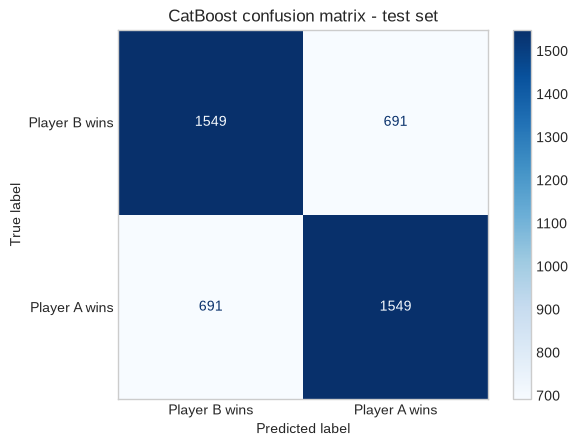

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Player B wins", "Player A wins"],
    cmap="Blues",
)
plt.title("CatBoost confusion matrix - test set")
plt.grid(False)
plt.show()

### Precision, recall and F1-score

In [9]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Player B wins", "Player A wins"],
        digits=4,
    )
)

               precision    recall  f1-score   support

Player B wins     0.6915    0.6915    0.6915      2240
Player A wins     0.6915    0.6915    0.6915      2240

     accuracy                         0.6915      4480
    macro avg     0.6915    0.6915    0.6915      4480
 weighted avg     0.6915    0.6915    0.6915      4480



### ROC curve

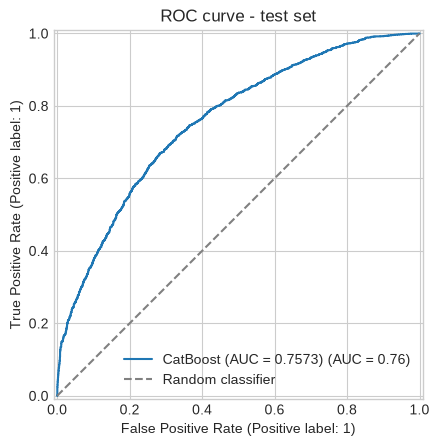

In [10]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    name=f"CatBoost (AUC = {test_auc:.4f})",
)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.title("ROC curve - test set")
plt.legend()
plt.show()

## 7. Feature importance

Tree-based models expose a feature-importance score. The score
indicates how much each feature contributes to the decisions of the ensemble.
As discussed in the course, importance is useful for interpretation, but it
does not prove that a feature causes the prediction.

,importance
loser_implied_prob_avg,16.219213
implied_prob_diff_avg,14.496559
winner_market_prob_normalized,13.918622
loser_market_prob_normalized,13.203903
normalized_market_prob_diff,12.710898
winner_implied_prob_avg,12.628452
market_overround_avg,1.907254
points_diff,0.824996
smoothed_surface_diff,0.785188
log_points_diff,0.772255


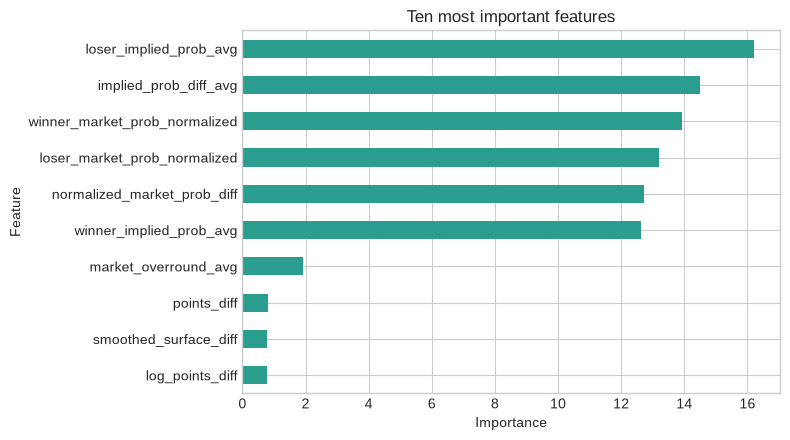

In [11]:
feature_importance = (
    pd.Series(
        np.asarray(model.feature_importances_, dtype=float),
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
)

display(feature_importance.head(10).to_frame())

ax = feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 4.5),
    color="#2a9d8f",
)
ax.set_title("Ten most important features")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Inspect the easiest and hardest matches

Rows are paired by `match_id_internal`, so every real match is
counted once. Confidence in the real winner is averaged across the two player
orientations. The most correct matches have the highest probability assigned
to the actual winner; the most wrong matches have the lowest.

In [12]:
holdout = dataset.iloc[test_index].copy()
holdout["actual_winner_probability"] = test_actual_winner_probability

pair_sizes = holdout.groupby("match_id_internal").size()
assert pair_sizes.eq(2).all(), "Each holdout match must have two orientations."

match_diagnostics = (
    holdout.loc[holdout["player_a_win"].eq(1)]
    .set_index("match_id_internal")
)
match_diagnostics["correct"] = (
    match_diagnostics["actual_winner_probability"] >= 0.5
)
match_diagnostics["predicted_winner"] = np.where(
    match_diagnostics["correct"],
    match_diagnostics["winner_name"],
    match_diagnostics["loser_name"],
)

assert len(match_diagnostics) * 2 == len(holdout)
print(f"Real holdout matches: {len(match_diagnostics):,}")
print(f"Match-level accuracy: {match_diagnostics['correct'].mean():.4f}")

Real holdout matches: 2,240
Match-level accuracy: 0.6915


### Most confident correct predictions

In [13]:
instance_columns = [
    "date",
    "winner_name",
    "loser_name",
    "predicted_winner",
    "surface",
    "round",
    "series",
    "winner_rank",
    "loser_rank",
    "normalized_market_prob_diff",
    "actual_winner_probability",
]

most_correct = match_diagnostics.nlargest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_correct)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
15120,2026-05-26,Sinner J.,Tabur C.,Sinner J.,Clay,1st Round,GrandSlam,1.0,171.0,0.951501,0.929540
14128,2026-01-22,Sinner J.,Duckworth J.,Sinner J.,Hard,2nd Round,GrandSlam,2.0,88.0,0.912781,0.928312
14041,2026-01-18,Alcaraz C.,Walton A.,Alcaraz C.,Hard,1st Round,GrandSlam,1.0,81.0,0.919426,0.928157
13415,2025-08-26,Sinner J.,Kopriva V.,Sinner J.,Hard,1st Round,GrandSlam,1.0,89.0,0.928823,0.928005
14892,2026-04-26,Sinner J.,Moller E.,Sinner J.,Clay,3rd Round,Masters1000,1.0,169.0,0.900394,0.925821
15464,2026-07-05,Sinner J.,Mochizuki S.,Sinner J.,Grass,4th Round,GrandSlam,1.0,151.0,0.884419,0.925629
14147,2026-01-24,Sinner J.,Spizzirri E.,Sinner J.,Hard,3rd Round,GrandSlam,2.0,85.0,0.940867,0.925579
14154,2026-01-26,Sinner J.,Darderi L.,Sinner J.,Hard,4th Round,GrandSlam,2.0,25.0,0.880702,0.925164
14975,2026-05-09,Sinner J.,Ofner S.,Sinner J.,Clay,2nd Round,Masters1000,1.0,82.0,0.900737,0.925052


### Most confident wrong predictions

In [14]:
most_wrong = match_diagnostics.nsmallest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_wrong)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
15145,2026-05-28,Cerundolo J.M.,Sinner J.,Sinner J.,Clay,2nd Round,GrandSlam,56.0,1.0,-0.917585,0.071256
13833,2025-10-28,Norrie C.,Alcaraz C.,Alcaraz C.,Hard,2nd Round,Masters1000,31.0,1.0,-0.818809,0.086928
14638,2026-03-30,Bennani K.,Halys Q.,Halys Q.,Clay,1st Round,ATP250,731.0,90.0,-0.805014,0.093940
15126,2026-05-26,Walton A.,Medvedev D.,Medvedev D.,Clay,1st Round,GrandSlam,97.0,8.0,-0.845577,0.098410
14374,2026-02-24,Kypson P.,De Minaur A.,De Minaur A.,Hard,1st Round,ATP500,103.0,6.0,-0.785208,0.102293
14637,2026-03-30,Baadi T.,Vukic A.,Vukic A.,Clay,1st Round,ATP250,587.0,84.0,-0.768398,0.106545
14159,2026-01-30,Djokovic N.,Sinner J.,Sinner J.,Hard,Semifinals,GrandSlam,4.0,2.0,-0.779381,0.111958
14337,2026-02-19,Mensik J.,Sinner J.,Sinner J.,Hard,Quarterfinals,ATP500,16.0,2.0,-0.778243,0.116735
15169,2026-05-30,Svajda Z.,Cerundolo F.,Cerundolo F.,Clay,3rd Round,GrandSlam,85.0,26.0,-0.756818,0.125347


### Numeric feature distributions: correct vs wrong

For each numeric feature, the table compares cohort medians,
missing-value rates and the mean shift measured in overall standard deviations.
Large absolute shifts identify where wrong predictions occupy a different part
of the feature distribution; they do not establish causality.

,feature,wrong_minus_correct_sd,correct_median,wrong_median,correct_missing_rate,wrong_missing_rate,absolute_shift,missing_rate_delta
15,winner_implied_prob_avg,-1.766895,0.719424,0.404858,0.000000,0.000000,1.766895,0.000000
17,implied_prob_diff_avg,-1.763825,0.378128,-0.250369,0.000000,0.000000,1.763825,0.000000
18,winner_market_prob_normalized,-1.760581,0.677570,0.381546,0.000000,0.000000,1.760581,0.000000
19,loser_market_prob_normalized,1.760581,0.322430,0.618454,0.000000,0.000000,1.760581,0.000000
20,normalized_market_prob_diff,-1.760581,0.355140,-0.236908,0.000000,0.000000,1.760581,0.000000
16,loser_implied_prob_avg,1.760446,0.341297,0.653595,0.000000,0.000000,1.760446,0.000000
68,elo_diff,-1.301973,123.102005,-83.631605,0.000000,0.000000,1.301973,0.000000
22,log_rank_diff,-1.268973,0.996978,-0.619039,0.000646,0.002894,1.268973,0.002249
71,surface_elo_diff,-1.240634,97.581008,-68.259373,0.000000,0.000000,1.240634,0.000000
24,log_points_diff,-1.236233,0.806407,-0.460558,0.000646,0.002894,1.236233,0.002249


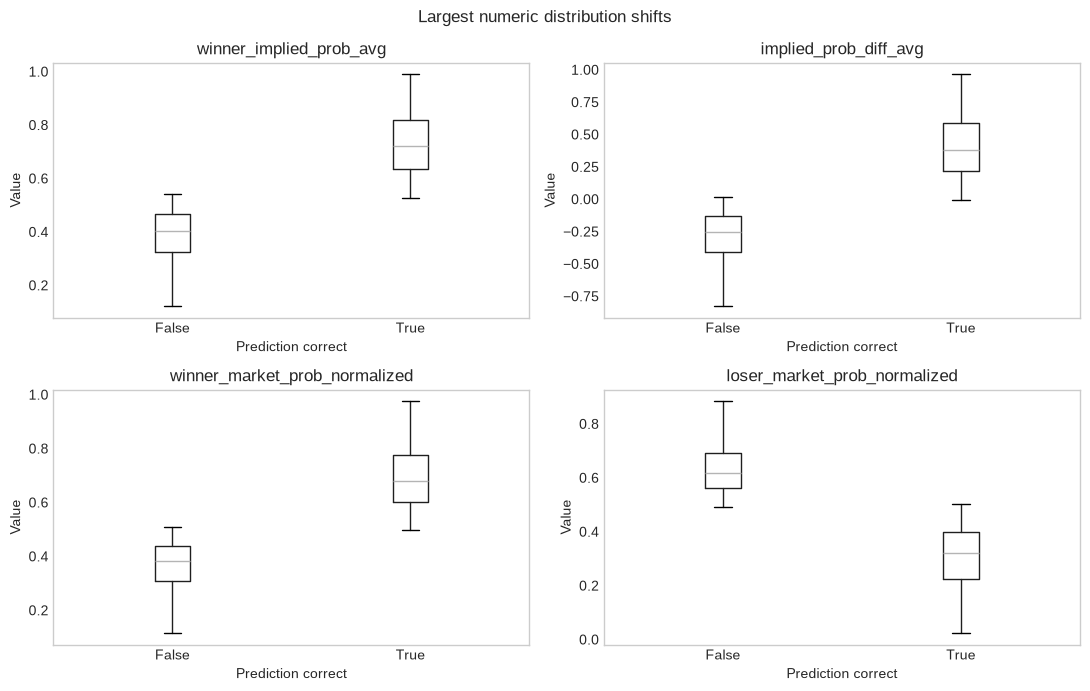

In [15]:
distribution_rows = []
for feature in numeric_features:
    correct_values = pd.to_numeric(
        match_diagnostics.loc[match_diagnostics["correct"], feature],
        errors="coerce",
    )
    wrong_values = pd.to_numeric(
        match_diagnostics.loc[~match_diagnostics["correct"], feature],
        errors="coerce",
    )
    overall_std = pd.to_numeric(
        match_diagnostics[feature], errors="coerce"
    ).std()
    standardized_shift = (
        (wrong_values.mean() - correct_values.mean()) / overall_std
        if overall_std > 0
        else np.nan
    )
    distribution_rows.append(
        {
            "feature": feature,
            "wrong_minus_correct_sd": standardized_shift,
            "correct_median": correct_values.median(),
            "wrong_median": wrong_values.median(),
            "correct_missing_rate": correct_values.isna().mean(),
            "wrong_missing_rate": wrong_values.isna().mean(),
        }
    )

numeric_distribution_shift = (
    pd.DataFrame(distribution_rows)
    .assign(
        absolute_shift=lambda frame: frame["wrong_minus_correct_sd"].abs(),
        missing_rate_delta=lambda frame: (
            frame["wrong_missing_rate"] - frame["correct_missing_rate"]
        ),
    )
    .sort_values("absolute_shift", ascending=False)
)
display(numeric_distribution_shift.head(15))

top_shift_features = numeric_distribution_shift.head(4)["feature"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for feature, axis in zip(top_shift_features, axes.ravel(), strict=True):
    match_diagnostics.boxplot(
        column=feature,
        by="correct",
        ax=axis,
        showfliers=False,
        grid=False,
    )
    axis.set_title(feature)
    axis.set_xlabel("Prediction correct")
    axis.set_ylabel("Value")
plt.suptitle("Largest numeric distribution shifts")
plt.tight_layout()
plt.show()

### Categorical feature distributions

In [16]:
overall_error_rate = 1 - match_diagnostics["correct"].mean()
categorical_rows = []
for feature in categorical_features:
    grouped = match_diagnostics.groupby(feature, dropna=False)["correct"].agg(
        matches="size",
        error_rate=lambda values: 1 - values.mean(),
    )
    grouped = grouped.loc[grouped["matches"] >= 20].reset_index()
    grouped.insert(0, "feature", feature)
    categorical_rows.append(grouped.rename(columns={feature: "value"}))

categorical_error_rates = pd.concat(categorical_rows, ignore_index=True)
categorical_error_rates["difference_from_overall"] = (
    categorical_error_rates["error_rate"] - overall_error_rate
)
categorical_error_rates["absolute_difference"] = categorical_error_rates[
    "difference_from_overall"
].abs()
categorical_error_rates = categorical_error_rates.sort_values(
    "absolute_difference", ascending=False
)
display(categorical_error_rates.head(15))

,feature,value,matches,error_rate,difference_from_overall,absolute_difference
31,tournament_bucket,Grand Prix Hassan II,25,0.480000,0.171518,0.171518
88,location_bucket,Marrakech,25,0.480000,0.171518,0.171518
24,tournament_bucket,Dallas Open,31,0.161290,-0.147192,0.147192
45,tournament_bucket,Qatar Exxon Mobil Open,31,0.161290,-0.147192,0.147192
75,location_bucket,Doha,31,0.161290,-0.147192,0.147192
73,location_bucket,Dallas,31,0.161290,-0.147192,0.147192
19,tournament_bucket,Barcelona Open,29,0.172414,-0.136068,0.136068
65,location_bucket,Barcelona,29,0.172414,-0.136068,0.136068
60,location_bucket,'s-Hertogenbosch,27,0.444444,0.135962,0.135962
48,tournament_bucket,Rosmalen Grass Court Championships,27,0.444444,0.135962,0.135962


### What is peculiar?

In [17]:
odds_importance_share = feature_importance.loc[
    [
        "winner_implied_prob_avg",
        "loser_implied_prob_avg",
        "implied_prob_diff_avg",
        "winner_market_prob_normalized",
        "loser_market_prob_normalized",
        "normalized_market_prob_diff",
    ]
].sum() / feature_importance.sum()
wrong_matches = match_diagnostics.loc[~match_diagnostics["correct"]]
upset_share = wrong_matches["normalized_market_prob_diff"].lt(0).mean()
largest_missing_gap = numeric_distribution_shift["missing_rate_delta"].abs().max()

print(f"Importance assigned to six odds features: {odds_importance_share:.1%}")
print(f"Wrong predictions where the actual winner was the market underdog: {upset_share:.1%}")
print(f"Largest correct/wrong missing-rate gap: {largest_missing_gap:.1%}")
print(
    "Interpretation: errors are mostly genuine upsets. Ranking, Elo, form and "
    "market-probability differences reverse direction in the wrong cohort. "
    "No comparably large missing-data anomaly is visible. Category-level "
    "differences should be treated cautiously because many groups are small."
)

Importance assigned to six odds features: 83.2%
Wrong predictions where the actual winner was the market underdog: 99.3%
Largest correct/wrong missing-rate gap: 3.8%
Interpretation: errors are mostly genuine upsets. Ranking, Elo, form and market-probability differences reverse direction in the wrong cohort. No comparably large missing-data anomaly is visible. Category-level differences should be treated cautiously because many groups are small.


## Conclusion

- The naive baseline obtains about **50% accuracy** because the classes are
  balanced.
- CatBoost's selection score is **neg_log_loss -0.5867** and its holdout accuracy is
  **0.6915**.
- The model improves clearly over the naive baseline.
- It ties the market baseline on accuracy, but the market remains slightly
  better on ROC AUC, log loss and Brier score. This run therefore does not
  demonstrate predictive advantage over the betting market.
- Market-implied probabilities are the most important features. Therefore,
  part of the predictive power comes from information already contained in
  betting odds.
- The most confident mistakes are mainly upsets in which rankings, Elo, form
  and betting odds all favored the eventual loser. There is no similarly large
  missing-value anomaly separating correct and wrong predictions.
- The difference between training and test accuracy should be monitored: a
  much larger training score would indicate over-fitting.

The final test set is used only once for evaluation. Any future change to the
features or CatBoost parameters must be selected using the training
cross-validation folds, not this test result.